# Problem 5

### Problem
$$
\begin{align*}
u(x, y) &= \sin(\alpha \pi (x + y)), \\
\end{align*}
$$

From the Paper:
This solution and the respective function $f(x, y) = -2 \alpha^{2} \pi^{2} \sin(\alpha \pi (x + y))$ present rapidly growing derivatives for large values of $\alpha$. In Tables VIII and IX we present relative errors in the norm $\|\cdot\|_{\infty}$ when solving the Dirichlet problem for $\alpha = 5$ and $\alpha = 20$, respectively. Here we have adopted the trapezoidal rule for evaluating the radial integrals.

For the case $\alpha = 5$ the dominant parameter is the number of circles $M$ regardless of the number of Fourier coefficients in use. In fact, quadratic convergence depending on $M$ can be observed in Table VIII. For the larger value $\alpha = 20$ functions $u$ and $f$ oscillate rapidly, and the derivatives increase in absolute value.

The Fourier spaces of dimension $N = 64$ and $N = 128$ do not allow a good representation of $u$ and $f$ as one can observe on the first two rows of relative residual in Table IX. However, for $N = 256$ or larger, the Fourier space provides a good representation of these functions, and the quadratic convergence on $M$ resumes (rows 3, 4, 5, and 6 in Table IX). This problem shows the importance of using Fourier representation when dealing with rapidly oscillating functions.

# Imports

In [1]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp

import os, sys

# Main project root
repo_root = r"C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)


from Tests.JCP_Paper_Comparisons.JCP_Helpers import (
    get_problem_functions,
    run_table_2,
    display_table_varying_M
)




# Problem Setup

In [2]:
from Tests.JCP_Paper_Comparisons.JCP_Helpers import setup_problem_5

alpha = 5  # Can also be set to 20 based on paper
u, f, g_dirichlet, g_neumann = setup_problem_5(alpha)

R = 1.0
rad_unif = 0
BC_MAP = {"dirichlet": 1, "neumann": 2}
QUAD_MAP = {"trapezoidal": 1, "simpson": 2}

methods = [
    {"name": "nufft", "label": "NUFFT Method", "azu_unif": 1, "mesh_kind": "rand", "use_nudft": False}
]

N_fixed = 256
M_values = [16, 32, 64, 128]


# Run Code, table 

In [3]:
df_table = run_table_2(methods, N_fixed, M_values, u, f, g_dirichlet, g_neumann, BC_MAP, QUAD_MAP, rad_unif, R)


C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\nonuniform.py:143: RuntimeWarning: divide by zero encountered in scalar divide
  * (r_ip1 / r_im1) ** k
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\nonuniform.py:143: RuntimeWarning: divide by zero encountered in scalar divide
  * (r_ip1 / r_im1) ** k
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]
C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\nonuniform.py:143: RuntimeWarning: divide by zero encountered in scalar divide
  * (r_ip1 / r_im1) ** k
C:\Users\charl\OneDrive\Docume

# View Results

In [4]:
display_table_varying_M(df_table, methods, M_values, title=f"PROBLEM 5 (alpha={alpha})")



NUFFT Method : PROBLEM 5 (alpha=5)


Trapezoidal rule                             Simpson rule           \
           Dirichlet            Neumann             Dirichlet            
           L_inf_rel   L2_rel L_inf_rel   L2_rel    L_inf_rel   L2_rel   
M                                                                        
16           5.8e+00  2.0e+00   3.6e+00  1.7e+00      9.8e+00  3.1e+00   
32           2.8e+00  1.3e+00   3.8e+00  1.7e+00      3.2e+00  1.3e+00   
64           2.1e+00  1.1e+00   4.0e+00  2.0e+00      2.1e+00  1.1e+00   
128          2.1e+00  1.1e+00   4.0e+00  2.0e+00      2.1e+00  1.1e+00   

                        
      Neumann           
    L_inf_rel   L2_rel  
M                       
16    7.8e+00  2.7e+00  
32    3.9e+00  1.8e+00  
64    4.0e+00  2.1e+00  
128   4.0e+00  2.0e+00

## Figures from Original Paper

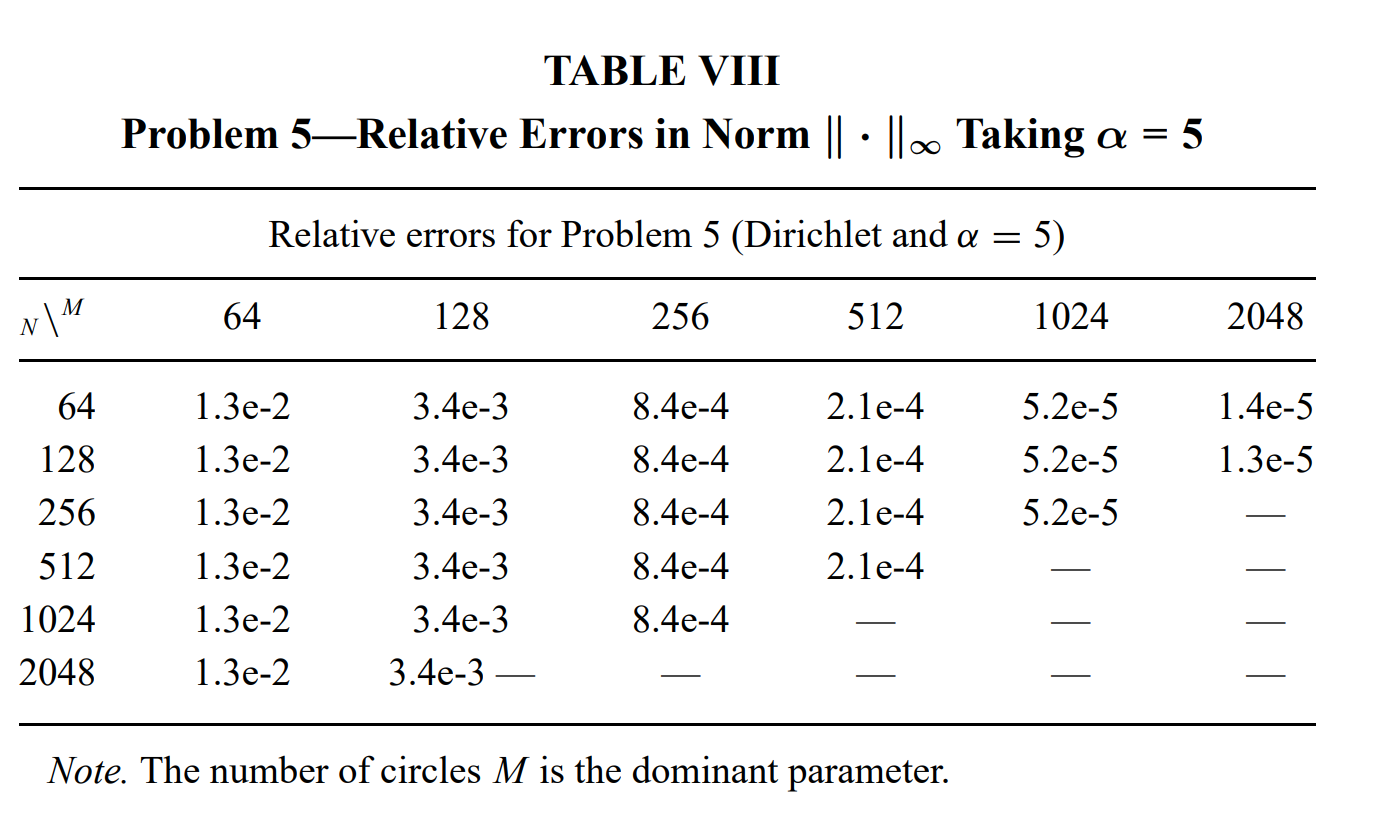

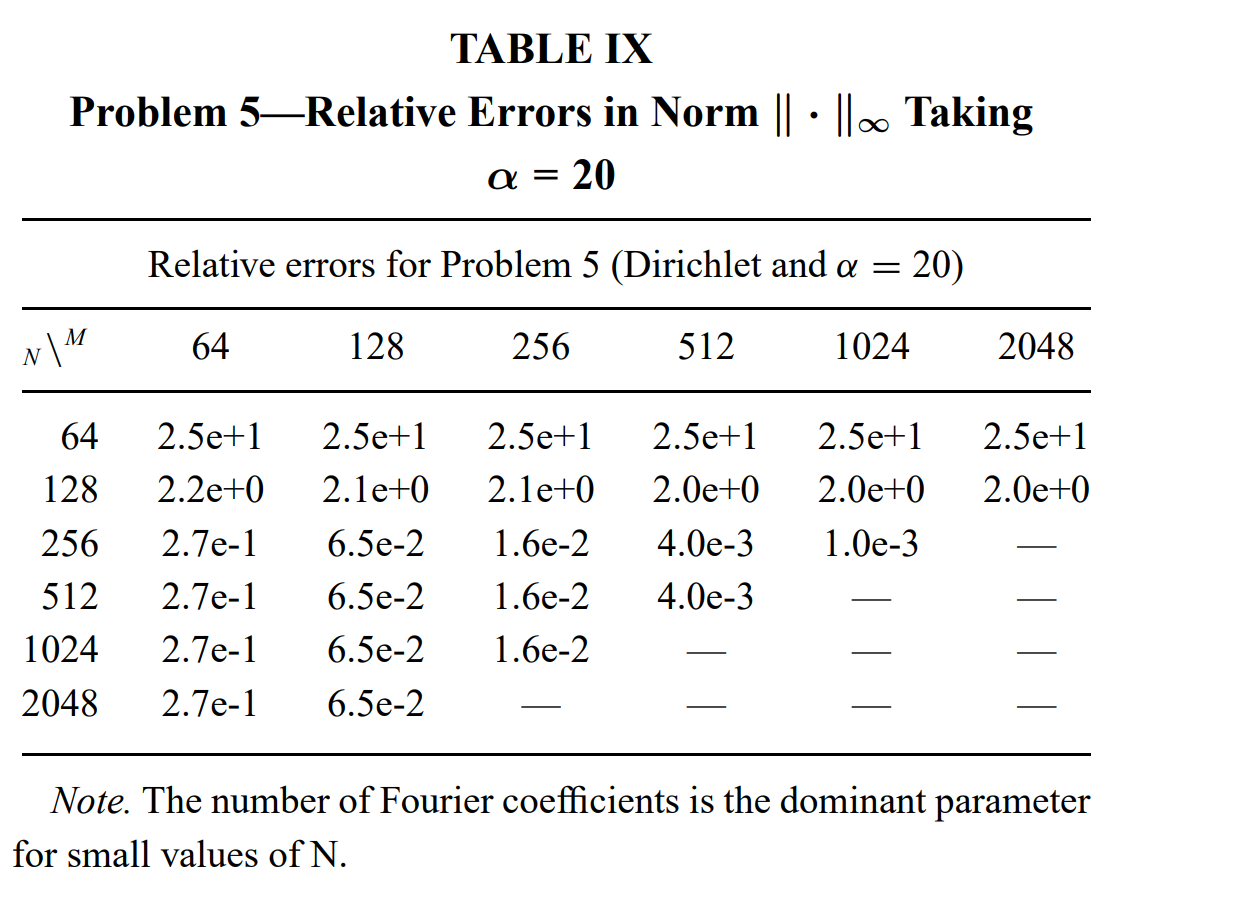